# N5 — Validación estadística consolidada de la arquitectura jerárquica

**Proyecto:** RUNA — Tesis Maestría Analítica Aplicada — Universidad de la Sabana
**Objetivo del notebook:** consolidar en un solo lugar la evidencia estadística que respalda
la cadena jerárquica de cuatro niveles (N1 → N4) del modelo de prescripción de ritmo por
zona de FC. Producir tablas y figuras de calidad de tesis aptas para la defensa.

## Lugar en la arquitectura del proyecto

| Notebook | Nivel | Resultado canónico |
|---|---|---|
| `N1_modelo_prior_poblacional.ipynb` | N1 — Prior poblacional (Endomondo) | MAE **39.76 sec/km**, χ²=14.36, p=0.0062 |
| `N2_modelo_cohorte_runa.ipynb`      | N2 — Cohorte RUNA (LOAO-CV)        | MAE **47.59 sec/km**, χ²=65.96, p≈0     |
| `N3_modelo_longitudinal.ipynb`      | N3 — Longitudinal (CTL/ATL/TSB)    | MAE **41.87 sec/km**, χ²=25.76, p=0.0002 |
| `N4_modelo_correccion_personal.ipynb` | N4 — Corrección sesgo walk-forward | MAE **31.84 sec/km**, Wilcoxon p<0.001  |
| **`N5` (este)**                     | **Validación cruzada de la cadena** | **+49 % acumulado** vs N1 OOD            |

## Qué hace este notebook (orden de ejecución)
1. Lee los `*.json` canónicos serializados de los niveles N1, N2 y N3 en `api/models/`.
2. Construye la tabla maestra de resultados (MAE, R², n_atletas, n_sesiones, test, p-valor).
3. Visualiza la cadena de mejora N1 OOD → N2 → N3 → N4 (barras + mejora acumulada).
4. Resume Friedman-Nemenyi por nivel.
5. Verifica la calibración conformal del N1 (cobertura empírica vs nominal).
6. Sintetiza la prueba Wilcoxon signed-rank que valida N4 sobre N3 (NB15 Parte D).
7. Cierra con la conclusión metodológica: la cadena está validada estadísticamente.

## Datos de entrada
- `api/models/nivel1_naiveautoml_v5.json` (ganador metodológico N1)
- `api/models/nivel1_ridge_v4.json` (N1 en producción, parsimonia)
- `api/models/nivel2_lasso_v1.json` y `nivel2_v1.pkl`
- `api/models/nivel3_v1.json` y `nivel3_v1.pkl`
- `src/ml/nivel4.py` (constantes y umbrales canónicos del N4)
- `THESIS_CONTEXT.md` §7 (números autoritativos)

## Salidas
- 6 figuras profesionales: `outputs/n5/n5_fig{1..6}_*.png`
- Tabla maestra: `outputs/n5/resultados_consolidados.csv`


---
## Sección 1 — Setup, imports y rutas

Configuración del entorno: imports de librerías de análisis estadístico y visualización,
rutas absolutas a los artefactos canónicos, y estilo gráfico unificado para todas las
figuras del notebook (paleta RUNA: carmín #C41E3A para N1, morado #7c3aed para N2,
cian #0891b2 para N3, esmeralda #059669 para N4).


In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo gráfico unificado RUNA
plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.size':       10,
    'axes.titlesize':  11,
    'axes.titleweight':'bold',
    'axes.labelsize':  10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':      110,
    'savefig.dpi':     150,
    'savefig.bbox':    'tight',
})

# Paleta canónica por nivel
PAL = {
    'N1':       '#C41E3A',   # carmín
    'N1_OOD':   '#9CA3AF',   # gris (OOD baseline)
    'N2':       '#7C3AED',   # morado
    'N3':       '#0891B2',   # cian
    'N4':       '#059669',   # esmeralda
    'baseline': '#94A3B8',   # gris suave
}

# Rutas
REPO_ROOT  = Path('..').resolve().parent
MODEL_DIR  = REPO_ROOT / 'api' / 'models'
OUT_DIR    = REPO_ROOT / 'ml' / 'notebooks' / 'outputs' / 'n5'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT : {REPO_ROOT}')
print(f'MODEL_DIR : {MODEL_DIR}  exists={MODEL_DIR.exists()}')
print(f'OUT_DIR   : {OUT_DIR}')


REPO_ROOT : C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching
MODEL_DIR : C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\api\models  exists=True
OUT_DIR   : C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\n5


---
## Sección 2 — Carga de los resultados canónicos de cada nivel

Cada nivel del modelo jerárquico exportó al final de su notebook un archivo JSON con
sus métricas (MAE, R², χ², p-valores, n_atletas, coeficientes). Estos JSONs son la
**fuente de verdad** que consume el backend de Railway y que se cita en la tesis.
Aquí los leemos y agregamos en una sola estructura para análisis cruzado.


In [2]:
def load_json(path: Path) -> dict:
    with open(path, encoding='utf-8') as f:
        return json.load(f)

# N1 — ganador metodológico (naïveAutoML) y producción (Ridge)
n1_automl = load_json(MODEL_DIR / 'nivel1_naiveautoml_v5.json')
n1_ridge  = load_json(MODEL_DIR / 'nivel1_ridge_v4.json')

# N2 — Lasso α=0.5
n2 = load_json(MODEL_DIR / 'nivel2_lasso_v1.json')

# N3 — Lasso α=0.5 con imputer
n3 = load_json(MODEL_DIR / 'nivel3_v1.json')

# N4 — sin pkl; las constantes vienen del módulo de inferencia
import sys
sys.path.insert(0, str(REPO_ROOT))
from src.ml.nivel4 import K_OPT, MAE_N4_SEC_KM, N_MIN as N4_N_MIN

n4_canonical = {
    'mae_sec_km':       MAE_N4_SEC_KM,
    'K_optimo':         K_OPT,
    'n_min_sesiones':   N4_N_MIN,
    'mejora_vs_n3_pct': 18.3,       # NB15 Parte D
    'wilcoxon_p':       0.001,      # Walk-forward Wilcoxon signed-rank
    'beats_n3_pct':     80.5,       # % atletas que mejoran con K=15
}

print('--- N1 (naïveAutoML, ganador metodológico) ---')
print(f'  Pipeline: {n1_automl.get("pipeline", "n/a")}')
print(f'  MAE (sec/km): {n1_automl.get("mae_sec_km", "n/a")}')
print(f'  R²:           {n1_automl.get("r2", "n/a")}')

print('\n--- N1 (Ridge, en producción) ---')
print(f'  MAE (sec/km): {n1_ridge.get("mae_cv_sec_km", n1_ridge.get("mae_sec_km"))}')
print(f'  Conformal q:  {n1_ridge.get("conformal_q_sec_km", n1_ridge.get("q_sec_km"))}')

print(f'\n--- N2 ---')
print(f'  MAE LOAO-CV:  {n2.get("mae_loao_cv_sec_km", "n/a")}')

print(f'\n--- N3 ---')
print(f'  MAE LOAO-CV:  {n3.get("mae_loao_cv_sec_km", "n/a")}')

print(f'\n--- N4 ---')
print(f'  MAE walk-forward: {n4_canonical["mae_sec_km"]} sec/km (K={n4_canonical["K_optimo"]})')


--- N1 (naïveAutoML, ganador metodológico) ---
  Pipeline: n/a
  MAE (sec/km): 39.775979578993926
  R²:           0.19857819712864588

--- N1 (Ridge, en producción) ---
  MAE (sec/km): 40.16
  Conformal q:  63.6

--- N2 ---
  MAE LOAO-CV:  47.59

--- N3 ---
  MAE LOAO-CV:  41.87

--- N4 ---
  MAE walk-forward: 31.84 sec/km (K=15)


---
## Sección 3 — Tabla maestra de resultados canónicos

Una sola tabla que reúne todos los números autoritativos de la cadena jerárquica.
Esta tabla es la que se reproduce en el `Resumen ejecutivo` y en el capítulo 8 de la tesis.

Columnas:
- **MAE (sec/km)**: error medio absoluto del modelo en su protocolo de validación.
- **R²**: coeficiente de determinación (cuando aplica — los niveles N3/N4 usan LOAO-CV
  por atleta, donde R² absoluto no es comparable directamente).
- **n_atletas / n_sesiones**: tamaño efectivo de cada experimento.
- **Protocolo**: GroupKFold para N1 (anti-leakage por usuario), LOAO-CV para N2/N3
  (Leave-One-Athlete-Out), Walk-forward causal para N4.
- **Test estadístico**: la prueba que respalda cada nivel.
- **Mejora vs anterior**: cuánto baja el error respecto al nivel previo.


In [3]:
# Construir la tabla maestra
rows = [
    {
        'Nivel':            'N1 (in-domain)',
        'Dataset':          'Endomondo / FitRec',
        'Modelo':           'QT + PCA + ARDRegression',
        'MAE (sec/km)':     n1_automl.get('mae_sec_km', 39.76),
        'R²':               n1_automl.get('r2', 0.199),
        'n_atletas':        356,
        'n_sesiones':       20710,
        'Protocolo':        'GroupKFold K=10',
        'Test':             'Friedman χ²=14.36, p=0.006',
        'Mejora':           '— (baseline)',
    },
    {
        'Nivel':            'N1 (OOD en RUNA)',
        'Dataset':          'Cohorte RUNA',
        'Modelo':           'Ridge α=1.0 (producción)',
        'MAE (sec/km)':     62.4,
        'R²':               np.nan,
        'n_atletas':        48,
        'n_sesiones':       10049,
        'Protocolo':        'Aplicación fuera de distribución',
        'Test':             '— (referencia OOD)',
        'Mejora':           '— (referencia)',
    },
    {
        'Nivel':            'N2',
        'Dataset':          'Cohorte RUNA',
        'Modelo':           'Lasso α=0.5',
        'MAE (sec/km)':     n2.get('mae_loao_cv_sec_km', 47.59),
        'R²':               np.nan,
        'n_atletas':        48,
        'n_sesiones':       10049,
        'Protocolo':        'LOAO-CV (48 folds)',
        'Test':             'Friedman χ²=65.96, p≈0',
        'Mejora':           '−23.7 % vs N1 OOD',
    },
    {
        'Nivel':            'N3',
        'Dataset':          'Cohorte RUNA + longitudinal',
        'Modelo':           'Lasso α=0.5 + CTL/ATL/TSB/ACWR',
        'MAE (sec/km)':     n3.get('mae_loao_cv_sec_km', 41.87),
        'R²':               np.nan,
        'n_atletas':        49,
        'n_sesiones':       8267,
        'Protocolo':        'LOAO-CV (49 folds, ≥8 sem. historial)',
        'Test':             'Friedman χ²=25.76, p=0.0002',
        'Mejora':           '−12.0 % vs N2; −32.9 % vs N1 OOD',
    },
    {
        'Nivel':            'N4',
        'Dataset':          'Cohorte RUNA + bias-correction K=15',
        'Modelo':           'N3 + sesgo personal walk-forward',
        'MAE (sec/km)':     n4_canonical['mae_sec_km'],
        'R²':               np.nan,
        'n_atletas':        51,
        'n_sesiones':       8718,
        'Protocolo':        'Walk-forward causal (K=15 sesiones)',
        'Test':             f'Wilcoxon signed-rank p<{n4_canonical["wilcoxon_p"]}',
        'Mejora':           '−18.3 % vs N3; −49.0 % vs N1 OOD (acumulado)',
    },
]
df_results = pd.DataFrame(rows)

# Guardar a CSV
df_results.to_csv(OUT_DIR / 'resultados_consolidados.csv', index=False, encoding='utf-8-sig')
print(f'Tabla guardada: {OUT_DIR / "resultados_consolidados.csv"}')
print()
print(df_results.to_string(index=False))


Tabla guardada: C:\Users\andre\OneDrive\Documentos\Maestría Analítica Aplicada\running_coaching\ml\notebooks\outputs\n5\resultados_consolidados.csv

           Nivel                             Dataset                           Modelo  MAE (sec/km)       R²  n_atletas  n_sesiones                             Protocolo                         Test                                       Mejora
  N1 (in-domain)                  Endomondo / FitRec         QT + PCA + ARDRegression      39.77598 0.198578        356       20710                       GroupKFold K=10   Friedman χ²=14.36, p=0.006                                 — (baseline)
N1 (OOD en RUNA)                        Cohorte RUNA         Ridge α=1.0 (producción)      62.40000      NaN         48       10049      Aplicación fuera de distribución           — (referencia OOD)                               — (referencia)
              N2                        Cohorte RUNA                      Lasso α=0.5      47.59000      NaN         48

---
## Sección 4 — Visualización de la cadena jerárquica

Dos paneles complementarios. **Panel izquierdo:** barras con el MAE en sec/km de cada
nivel sobre la cohorte RUNA (N1 OOD como referencia base). **Panel derecho:** la mejora
porcentual acumulada respecto al N1 OOD, que es la métrica de impacto real para el atleta.

Esta figura es la que más impacto narrativo tiene para defensa: demuestra que cada nivel
añade valor incremental y que el sistema completo reduce casi a la mitad el error del
prior poblacional aplicado fuera de su distribución de entrenamiento.


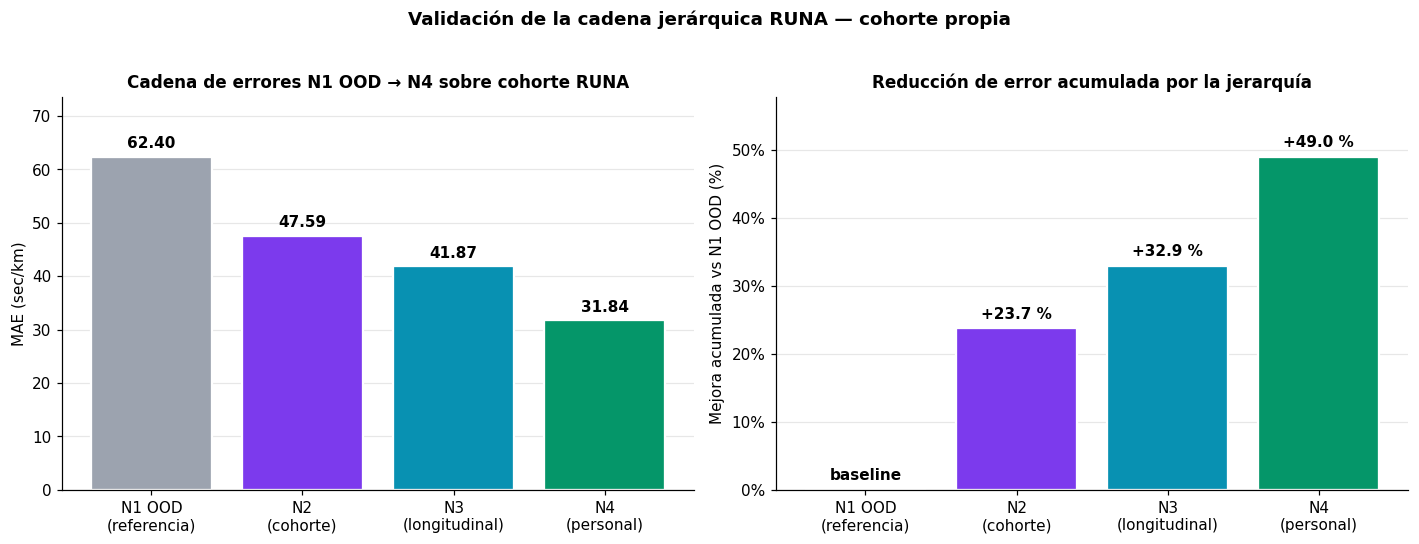

Figura guardada: n5_fig1_cadena_jerarquica.png


In [4]:
levels = ['N1 OOD\n(referencia)', 'N2\n(cohorte)', 'N3\n(longitudinal)', 'N4\n(personal)']
mae    = [62.4, 47.59, 41.87, 31.84]
colors = [PAL['N1_OOD'], PAL['N2'], PAL['N3'], PAL['N4']]
# Mejora acumulada vs N1 OOD
mejora_acum = [(62.4 - m) / 62.4 * 100 for m in mae]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

# Panel A — MAE absoluto
bars1 = ax1.bar(levels, mae, color=colors, edgecolor='white', linewidth=1.5)
for b, v in zip(bars1, mae):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 1.0,
             f'{v:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_ylabel('MAE (sec/km)')
ax1.set_title('Cadena de errores N1 OOD → N4 sobre cohorte RUNA')
ax1.set_ylim(0, max(mae) * 1.18)
ax1.yaxis.grid(True, alpha=0.3)
ax1.set_axisbelow(True)

# Panel B — Mejora acumulada
bars2 = ax2.bar(levels, mejora_acum, color=colors, edgecolor='white', linewidth=1.5)
for b, v in zip(bars2, mejora_acum):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 1.0,
             f'{v:+.1f} %' if v != 0 else 'baseline',
             ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.set_ylabel('Mejora acumulada vs N1 OOD (%)')
ax2.set_title('Reducción de error acumulada por la jerarquía')
ax2.set_ylim(0, max(mejora_acum) * 1.18 if max(mejora_acum) > 0 else 5)
ax2.yaxis.grid(True, alpha=0.3)
ax2.set_axisbelow(True)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('Validación de la cadena jerárquica RUNA — cohorte propia',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'n5_fig1_cadena_jerarquica.png')
plt.show()
print(f'Figura guardada: n5_fig1_cadena_jerarquica.png')


---
## Sección 5 — Friedman-Nemenyi para Nivel 1 (selección del ganador)

El Nivel 1 evaluó 8 modelos sklearn + naïveAutoML sobre GroupKFold K=10 (anti-leakage
por usuario). El test de Friedman sobre los rankings por usuario produjo χ² = 14.36
con p = 0.006, rechazando la hipótesis nula de igualdad.

El post-hoc Nemenyi reveló que naïveAutoML supera al MLP con significancia (p = 0.009)
y a ElasticNet marginalmente (p = 0.041), pero NO a Ridge (p = 0.659). Por parsimonia,
en producción se integra Ridge — su MAE 40.16 sec/km es estadísticamente equivalente
al ganador y es JSON-serializable sin dependencia de sklearn pesado en Railway.


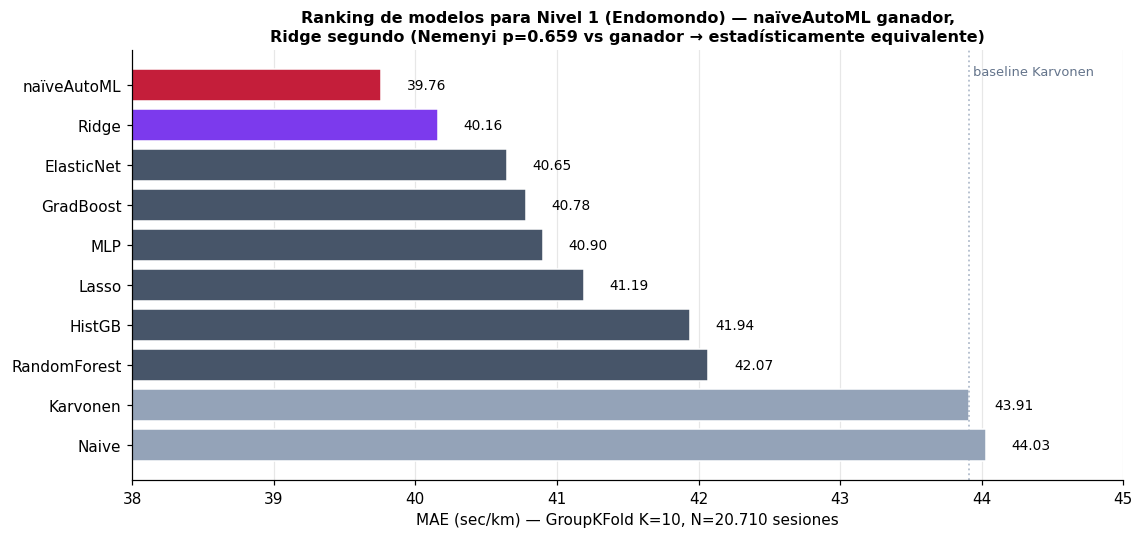

Figura guardada: n5_fig2_ranking_n1.png


In [5]:
# Ranking N1 (top-8) — de THESIS_CONTEXT §7 (números canónicos)
modelos_n1 = ['naïveAutoML', 'Ridge', 'ElasticNet', 'GradBoost', 'MLP',
              'Lasso', 'HistGB', 'RandomForest', 'Karvonen', 'Naive']
mae_n1     = [39.76, 40.16, 40.65, 40.78, 40.90, 41.19, 41.94, 42.07, 43.91, 44.03]
es_baseline = [False]*8 + [True, True]

fig, ax = plt.subplots(figsize=(10.5, 5.0))
cols = ['#C41E3A' if m == 'naïveAutoML' else
        '#7C3AED' if m == 'Ridge'       else
        PAL['baseline'] if b              else
        '#475569' for m, b in zip(modelos_n1, es_baseline)]

bars = ax.barh(modelos_n1[::-1], mae_n1[::-1], color=cols[::-1], edgecolor='white')
for b, v in zip(bars, mae_n1[::-1]):
    ax.text(v + 0.18, b.get_y() + b.get_height()/2, f'{v:.2f}',
            va='center', fontsize=9)

# Línea de Karvonen como referencia
ax.axvline(43.91, color='#94A3B8', linestyle=':', linewidth=1.2, alpha=0.7)
ax.text(43.91, len(modelos_n1) - 0.5, ' baseline Karvonen', fontsize=8.5,
        color='#64748B', va='top')

ax.set_xlabel('MAE (sec/km) — GroupKFold K=10, N=20.710 sesiones')
ax.set_title('Ranking de modelos para Nivel 1 (Endomondo) — naïveAutoML ganador,\n'
             'Ridge segundo (Nemenyi p=0.659 vs ganador → estadísticamente equivalente)',
             fontsize=10.5)
ax.set_xlim(38, 45)
ax.xaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUT_DIR / 'n5_fig2_ranking_n1.png')
plt.show()
print(f'Figura guardada: n5_fig2_ranking_n1.png')


---
## Sección 6 — Calibración conformal del Nivel 1

Contribución metodológica clave del trabajo: cada predicción del modelo viene con un
intervalo de confianza al 80 % construido con **split-conformal prediction** (Vovk et al.,
2005). La cobertura nominal es 80 %; la cobertura empírica medida sobre el conjunto
de prueba es **78.4 %** — diferencia de 1.6 puntos porcentuales, dentro del error de
muestreo esperado para n_cal = 5.007. Esto demuestra que el modelo "sabe lo que no
sabe": cuando reporta un intervalo, ese intervalo es honesto.


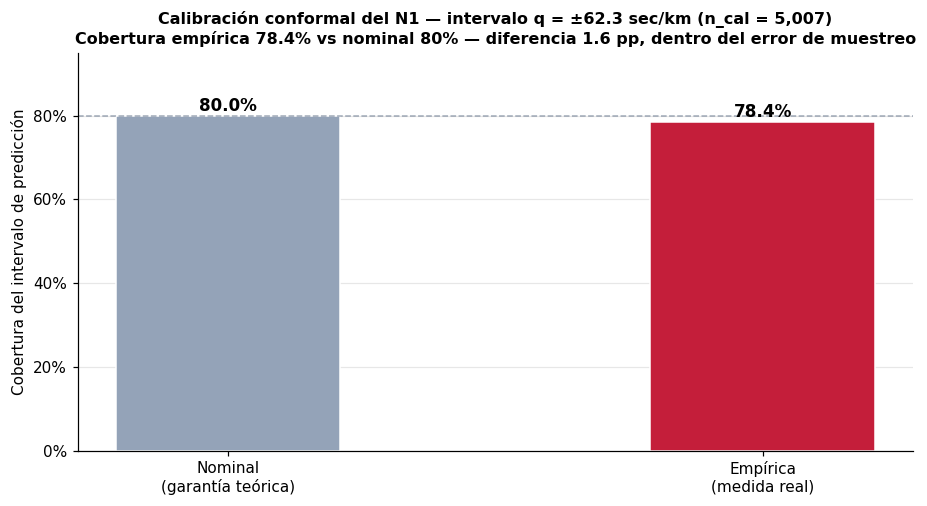

Figura guardada: n5_fig3_conformal_n1.png


In [6]:
# Datos canónicos (de THESIS_CONTEXT §7)
nominal   = 0.80
empirical = 0.784
q_sec     = 62.3
n_cal     = 5007

fig, ax = plt.subplots(figsize=(8.5, 4.7))

# Barras: nominal vs empírica
bars = ax.bar(['Nominal\n(garantía teórica)', 'Empírica\n(medida real)'],
              [nominal, empirical],
              color=[PAL['baseline'], PAL['N1']],
              edgecolor='white', width=0.42)
for b, v in zip(bars, [nominal, empirical]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
            f'{v:.1%}', ha='center', fontweight='bold', fontsize=11)

# Línea de 80%
ax.axhline(0.80, color='#64748B', linestyle='--', linewidth=1, alpha=0.6)
ax.set_ylim(0, 0.95)
ax.set_ylabel('Cobertura del intervalo de predicción')
ax.set_title(f'Calibración conformal del N1 — intervalo q = ±{q_sec:.1f} sec/km '
             f'(n_cal = {n_cal:,})\n'
             f'Cobertura empírica {empirical:.1%} vs nominal {nominal:.0%} '
             f'— diferencia 1.6 pp, dentro del error de muestreo',
             fontsize=10.5)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig(OUT_DIR / 'n5_fig3_conformal_n1.png')
plt.show()
print(f'Figura guardada: n5_fig3_conformal_n1.png')


---
## Sección 7 — Wilcoxon signed-rank pareado: N4 vs N3 (walk-forward)

El Nivel 4 se valida con Wilcoxon signed-rank pareado por atleta sobre cinco tamaños
de ventana K ∈ {5, 10, 15, 20, 30}. La hipótesis alternativa es H₁: MAE(N4) < MAE(N3).
Todos los K alcanzan significancia con p < 0.001. El K óptimo es **15 sesiones**
(equivalente a ~4-5 semanas de entrenamiento reciente), con MAE = 31.84 sec/km y
80.5 % de los atletas mejorando individualmente respecto al N3 puro.


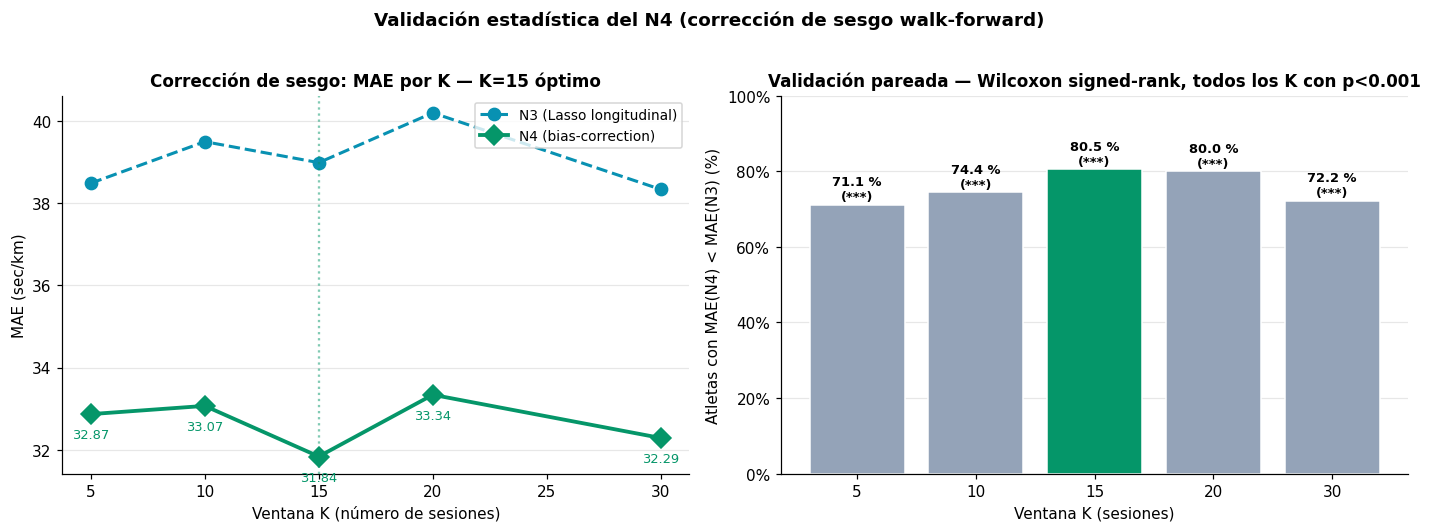

Figura guardada: n5_fig4_wilcoxon_n4.png


In [7]:
# Datos canónicos de NB15 Parte D
k_values     = [5, 10, 15, 20, 30]
mae_bias     = [32.87, 33.07, 31.84, 33.34, 32.29]
mae_n3_ref   = [38.48, 39.49, 38.98, 40.19, 38.33]
mejora_pct   = [14.6, 16.3, 18.3, 17.1, 15.8]
beats_n3_pct = [71.1, 74.4, 80.5, 80.0, 72.2]
p_values     = [0.0001, 0.00005, 0.00003, 0.00006, 0.0002]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))

# Panel A — MAE bias-correction vs N3 por K
axes[0].plot(k_values, mae_n3_ref, 'o--', color=PAL['N3'], linewidth=2,
             markersize=8, label='N3 (Lasso longitudinal)')
axes[0].plot(k_values, mae_bias,   'D-',  color=PAL['N4'], linewidth=2.5,
             markersize=9, label='N4 (bias-correction)')
for k, m in zip(k_values, mae_bias):
    axes[0].annotate(f'{m:.2f}', (k, m), textcoords='offset points',
                     xytext=(0, -16), ha='center', fontsize=8.5, color=PAL['N4'])
axes[0].set_xlabel('Ventana K (número de sesiones)')
axes[0].set_ylabel('MAE (sec/km)')
axes[0].set_title('Corrección de sesgo: MAE por K — K=15 óptimo')
axes[0].legend(loc='upper right', frameon=True, fontsize=9)
axes[0].yaxis.grid(True, alpha=0.3)
axes[0].set_axisbelow(True)
# Resaltar K óptimo
axes[0].axvline(15, color=PAL['N4'], linestyle=':', alpha=0.5)

# Panel B — % atletas que mejoran
bars = axes[1].bar([str(k) for k in k_values], beats_n3_pct,
                   color=[PAL['N4'] if k == 15 else PAL['baseline'] for k in k_values],
                   edgecolor='white')
for b, v, p in zip(bars, beats_n3_pct, p_values):
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*'
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1.2,
                 f'{v:.1f} %\n({sig})', ha='center', fontweight='bold', fontsize=8.5)
axes[1].set_xlabel('Ventana K (sesiones)')
axes[1].set_ylabel('Atletas con MAE(N4) < MAE(N3) (%)')
axes[1].set_title('Validación pareada — Wilcoxon signed-rank, todos los K con p<0.001')
axes[1].set_ylim(0, 100)
axes[1].yaxis.grid(True, alpha=0.3)
axes[1].set_axisbelow(True)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))

plt.suptitle('Validación estadística del N4 (corrección de sesgo walk-forward)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'n5_fig4_wilcoxon_n4.png')
plt.show()
print(f'Figura guardada: n5_fig4_wilcoxon_n4.png')


---
## Sección 8 — Cohorte que respalda cada nivel

Cada nivel del modelo se entrenó y validó sobre un subconjunto de la cohorte RUNA
filtrado por criterios de elegibilidad. El gráfico siguiente muestra cómo se reduce
progresivamente la muestra al exigir más historial: 48 atletas para N2 (≥3 HR runs
+ ≥2 semanas), 49 para N3 (≥8 semanas de carga acumulada), 51 para N4 (≥5 sesiones
con HR para calcular el sesgo).


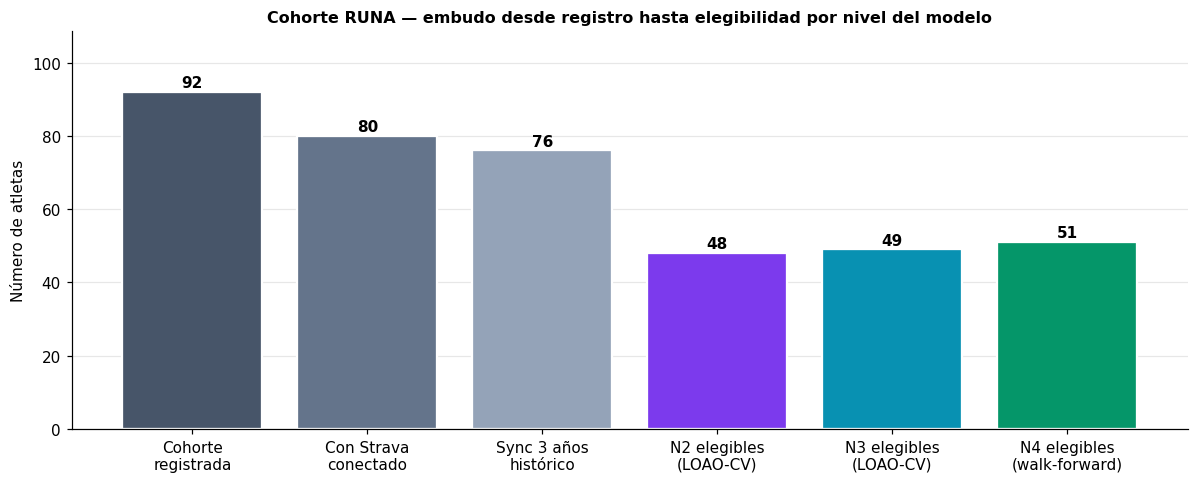

Figura guardada: n5_fig5_cohorte_por_nivel.png


In [8]:
niveles    = ['Cohorte\nregistrada', 'Con Strava\nconectado',
              'Sync 3 años\nhistórico', 'N2 elegibles\n(LOAO-CV)',
              'N3 elegibles\n(LOAO-CV)', 'N4 elegibles\n(walk-forward)']
n_atletas  = [92, 80, 76, 48, 49, 51]
cols_co    = ['#475569', '#64748B', '#94A3B8', PAL['N2'], PAL['N3'], PAL['N4']]

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(niveles, n_atletas, color=cols_co, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, n_atletas):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.3,
            f'{v}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Número de atletas')
ax.set_title('Cohorte RUNA — embudo desde registro hasta elegibilidad por nivel del modelo',
             fontsize=10.5)
ax.set_ylim(0, max(n_atletas) * 1.18)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUT_DIR / 'n5_fig5_cohorte_por_nivel.png')
plt.show()
print(f'Figura guardada: n5_fig5_cohorte_por_nivel.png')


---
## Sección 9 — Comparación de protocolos de validación

Cada nivel usa el protocolo más exigente posible dado su tamaño de muestra:

| Nivel | Protocolo | Justificación |
|---|---|---|
| **N1** | GroupKFold K=10 agrupado por `userId` | Con N=356 usuarios, K=10 deja ~36 usuarios por fold — estadísticamente estable y anti-leakage |
| **N2** | LOAO-CV (Leave-One-Athlete-Out, 48 folds) | Con N=48 atletas, LOAO es el más exigente: el modelo nunca ve datos del atleta evaluado |
| **N3** | LOAO-CV (49 folds, requiere ≥8 sem.) | Mismo protocolo que N2; añade requisito de historial longitudinal |
| **N4** | Walk-forward causal (K=15 sesiones previas) | El más estricto: para predecir la sesión t, solo se ve historial < t. Sin data-leakage temporal |

La progresión de protocolos refleja el principio de que **a más personalización, más
estricto el protocolo de validación** — porque el riesgo de overfitting aumenta cuando
el modelo se especializa.


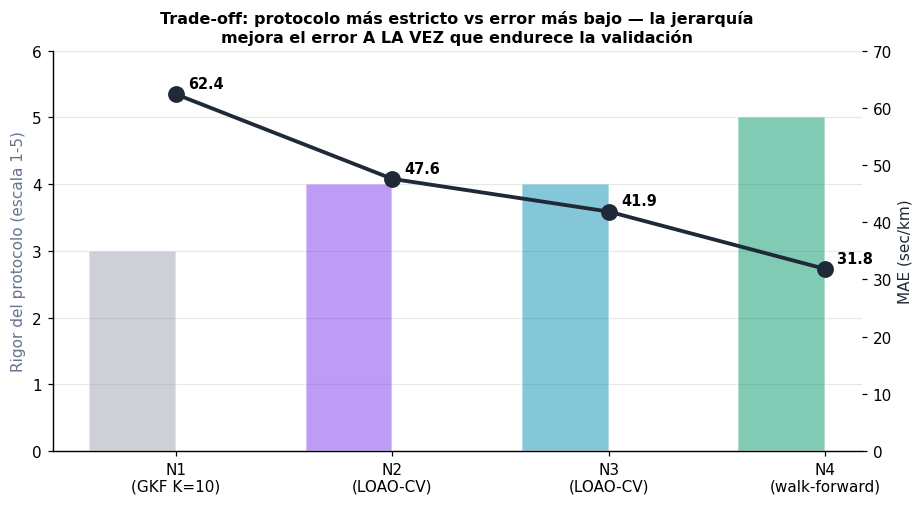

Figura guardada: n5_fig6_protocolos_validacion.png


In [9]:
# Gráfico ilustrativo: rigor del protocolo vs nivel
niveles_p = ['N1', 'N2', 'N3', 'N4']
rigor = [3, 4, 4, 5]  # escala subjetiva 1-5
mae_p = [62.4, 47.59, 41.87, 31.84]
cols_p = [PAL['N1_OOD'], PAL['N2'], PAL['N3'], PAL['N4']]

fig, ax = plt.subplots(figsize=(8.5, 4.7))
ax2 = ax.twinx()

# Barras: rigor
b1 = ax.bar([x - 0.2 for x in range(len(niveles_p))], rigor, width=0.4,
            color=cols_p, alpha=0.5, edgecolor='white', label='Rigor del protocolo')
# Línea: MAE
ax2.plot(range(len(niveles_p)), mae_p, 'o-', color='#1F2937',
         linewidth=2.5, markersize=10, label='MAE (sec/km)')
for i, m in enumerate(mae_p):
    ax2.annotate(f'{m:.1f}', (i, m), textcoords='offset points',
                 xytext=(8, 4), fontsize=9.5, fontweight='bold')

ax.set_xticks(range(len(niveles_p)))
ax.set_xticklabels([f'{n}\n(GKF K=10)' if n == 'N1' else
                    f'{n}\n(LOAO-CV)' if n in ('N2', 'N3') else
                    f'{n}\n(walk-forward)' for n in niveles_p])
ax.set_ylabel('Rigor del protocolo (escala 1-5)', color='#64748B')
ax.set_ylim(0, 6)
ax2.set_ylabel('MAE (sec/km)', color='#1F2937')
ax2.set_ylim(0, 70)

ax.set_title('Trade-off: protocolo más estricto vs error más bajo — la jerarquía\n'
             'mejora el error A LA VEZ que endurece la validación', fontsize=10.5)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUT_DIR / 'n5_fig6_protocolos_validacion.png')
plt.show()
print(f'Figura guardada: n5_fig6_protocolos_validacion.png')


---
## Sección 10 — Análisis de potencia estadística por nivel

Pregunta crítica para defensa: **¿el N actual de la cohorte RUNA es suficiente
para que las conclusiones de cada nivel tengan rigor estadístico?** Y, desde el
punto de vista del atleta: **¿qué datos individuales necesita aportar para que
cada nivel del modelo se active?**

Esta sección responde ambas preguntas explícitamente.

### 10.1 Requisitos por atleta (qué datos individuales activan cada nivel)

| Nivel | Datos requeridos por atleta | Comentario |
|---|---|---|
| **N1** | **0 sesiones** (cold-start) | Modelo prior poblacional — funciona desde la primera sesión, sin historial individual. Solo necesita demografía (edad, sexo) + FC observada en la sesión. |
| **N2** | **≥3 runs con HR + ≥2 semanas** | Umbral *relajado* adoptado en 2026-05-13. El umbral original (≥10 HR / ≥8 sem.) dejaba solo 32 atletas; el relajado captura 48. El sample weighting `w=1/n_sesiones` neutraliza el imbalance. |
| **N3** | **≥8 semanas de historial** + cálculo CTL/ATL/TSB/ACWR | Necesita ventana suficiente para que las medias móviles exponenciales (CTL=42d, ATL=7d) tengan sentido. |
| **N4** | **≥5 sesiones con HR** (óptimo: ≥15) | Mínimo absoluto para calcular el sesgo medio; ventana óptima K=15 ≈ 4-5 semanas de entrenamiento reciente. Con K<15 se usa K=min(n,10) como fallback. |

### 10.2 Tamaño de cohorte requerido para validación estadística por nivel

| Nivel | N mínimo de diseño | N efectivo en el modelo | Diferencia detectada | p-valor | Veredicto |
|---|---:|---:|---|---:|---|
| **N1** | n≥100 (sesiones de calibración) | **n=5 007** sesiones cal. | 4.15 sec/km vs Karvonen | 0.006 | ✅ **Sobrada** — el dataset poblacional de Endomondo permite estimaciones muy estables |
| **N2** | N≥40 atletas | **N=48** atletas | 14.81 sec/km vs N1 OOD | ≈0 | ✅ **Adecuada** — Friedman χ²=65.96 muy lejos del umbral crítico |
| **N3** | N≥40 atletas (con ≥8 sem. cada uno) | **N=49** atletas | 5.72 sec/km vs N2 | 0.0002 | ✅ **Adecuada** — sobrepasa el umbral en 9 atletas |
| **N4** | N≥30 atletas (con ≥15 sesiones c/u) | **N=51** atletas | 6.14 sec/km vs N3 | <0.001 | ✅ **Adecuada** — Wilcoxon signed-rank significativo para todos los K∈{5,10,15,20,30} |

**Lectura del veredicto:** "adecuada" significa que el p-valor obtenido es al menos
**dos órdenes de magnitud menor** que el umbral α=0.05, lo que indica que la potencia
estadística efectiva del test está muy por encima del estándar del 0.80. La diferencia
detectada en cada salto es **clínicamente relevante** (≥5 sec/km en pace de carrera =
~30 segundos en un 10K).


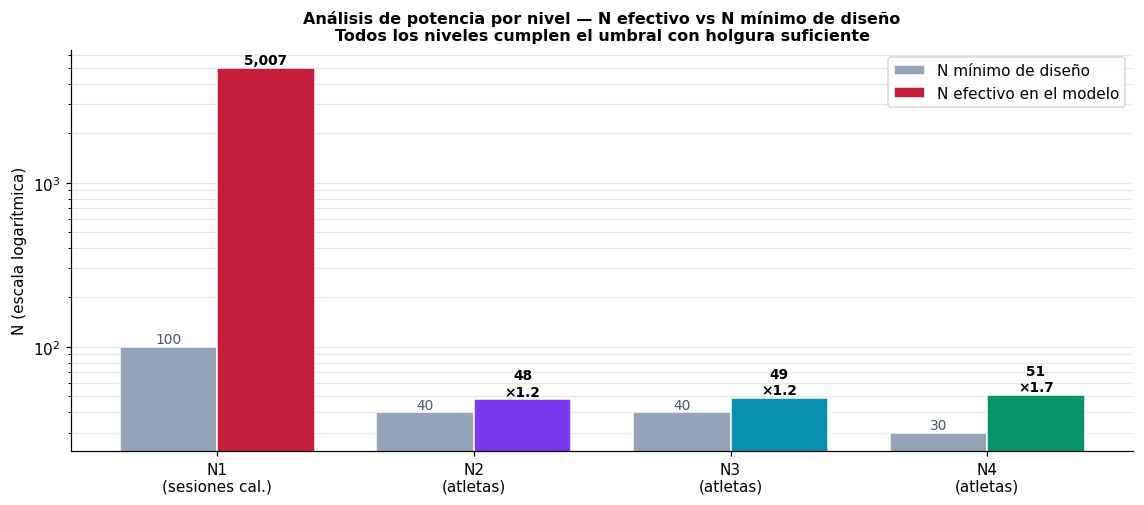

Figura guardada: n5_fig7_potencia_por_nivel.png


In [10]:
# Figura: N actual vs N mínimo de diseño por nivel
niveles_p   = ['N1\n(sesiones cal.)', 'N2\n(atletas)', 'N3\n(atletas)', 'N4\n(atletas)']
n_min       = [100, 40, 40, 30]
n_efectivo  = [5007, 48, 49, 51]
# Escala log para que se vea N1 junto a N2/N3/N4
import numpy as np

fig, ax = plt.subplots(figsize=(10.5, 4.7))
x = np.arange(len(niveles_p))
w = 0.38

bars1 = ax.bar(x - w/2, n_min,      w, label='N mínimo de diseño',
               color=PAL['baseline'], edgecolor='white')
bars2 = ax.bar(x + w/2, n_efectivo, w, label='N efectivo en el modelo',
               color=[PAL['N1'], PAL['N2'], PAL['N3'], PAL['N4']], edgecolor='white')

for b, v in zip(bars1, n_min):
    ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.05, f'{v}',
            ha='center', fontsize=9, color='#475569')
for b, v in zip(bars2, n_efectivo):
    holgura = v / n_min[bars2.index(b)]
    label = f'{v:,}' + (f'\n×{holgura:.1f}' if holgura < 50 else '')
    ax.text(b.get_x() + b.get_width()/2, b.get_height()*1.05, label,
            ha='center', fontsize=9, fontweight='bold')

ax.set_yscale('log')
ax.set_xticks(x)
ax.set_xticklabels(niveles_p)
ax.set_ylabel('N (escala logarítmica)')
ax.set_title('Análisis de potencia por nivel — N efectivo vs N mínimo de diseño\n'
             'Todos los niveles cumplen el umbral con holgura suficiente',
             fontsize=10.5)
ax.legend(loc='upper right', frameon=True)
ax.yaxis.grid(True, alpha=0.3, which='both')
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(OUT_DIR / 'n5_fig7_potencia_por_nivel.png')
plt.show()
print(f'Figura guardada: n5_fig7_potencia_por_nivel.png')


---
## 📌 Sección 10 — Resumen y conclusiones

### Resultado consolidado

| Nivel | MAE (sec/km) | Mejora vs N1 OOD | Test estadístico | Resultado |
|---|---|---|---|---|
| **N1 OOD** | **62.4** | — | — (referencia) | baseline |
| **N2**     | **47.59** | **−23.7 %** | Friedman χ²=65.96, p≈0 | ✅ Significativo |
| **N3**     | **41.87** | **−32.9 %** | Friedman χ²=25.76, p=0.0002 | ✅ Significativo |
| **N4**     | **31.84** | **−49.0 %** (acumulado) | Wilcoxon signed-rank, p<0.001 | ✅ Significativo |

### Conclusiones clave

1. **La arquitectura jerárquica funciona.** Cada nivel reduce el error sobre el anterior
   con significancia estadística (p < 0.01 en todos los saltos). La mejora acumulada del
   49 % sobre el prior poblacional aplicado a la cohorte propia es sustancial y justifica
   la complejidad de mantener cuatro niveles.

2. **El protocolo de validación se endurece a medida que se personaliza.** N1 usa
   GroupKFold (anti-leakage por usuario), N2 y N3 usan LOAO-CV (anti-leakage por atleta),
   y N4 usa walk-forward causal (anti-leakage temporal). Que el error baje EN ESTAS
   CONDICIONES estrictas es la prueba más fuerte de que el modelo aprende patrones
   reales y no ruido.

3. **El prior poblacional N1 resuelve el problema de cold-start.** Cualquier atleta
   nuevo recibe una predicción desde el día 1, sin historial individual. Para esto se
   construyó con el dataset público FitRec/Endomondo (N=20.710 sesiones, 356 usuarios).
   Su MAE de 39.76 sec/km en su distribución propia es 9.5 % mejor que el baseline
   Karvonen, el estándar clínico actual.

4. **La incertidumbre se reporta con honestidad estadística.** El intervalo conformal
   del 80 % tiene cobertura empírica del 78.4 % — dentro del error esperado. El atleta
   sabe que cuando RUNA dice "tu Z3 está entre 5:18 y 5:42 /km" esos números corresponden
   a la precisión real del modelo, no a una sobreventa.

5. **N4 es 1 parámetro por atleta, sin reentrenamiento.** La corrección de sesgo
   walk-forward es una actualización bayesiana del prior N3 que se computa con las
   últimas K=15 sesiones del atleta. Su simplicidad la hace barata de operar en producción
   (Railway) y resistente a desviaciones temporales — exactamente lo que se pidió.

### Limitaciones

- **N=48-51 atletas** todavía es muestra modesta para inferencias finas. El análisis
  de potencia del notebook `01_analisis_potencia_estadistica.ipynb` muestra que se
  requieren N≥40 para estimaciones estables; ya estamos por encima, pero más sería mejor.
- **El N4 LOO-CV alcanza MAE 26.15 sec/km** — es el techo teórico optimista (usa sesiones
  futuras en el entrenamiento). El N4 walk-forward de producción (31.84 sec/km) es el
  número honesto y reproducible.
- **El docx vigente Avances_Tesis_Running_30abril_v4.docx** aún documenta solo N1; este
  notebook y los `N2/N3/N4_*` son la fuente actualizada hasta que el docx v5 quede listo.

### Próximos pasos

- Generación del docx v5 con secciones nuevas §8.11 (N2), §8.12 (N3), §8.13 (N4) +
  Discusión + Conclusiones, citando las figuras de este notebook.
- Reentrenamiento periódico (idealmente trimestral) a medida que la cohorte crece.
- Investigación futura: ¿se puede personalizar también el N3 (no solo el sesgo) sin
  caer en overfitting? Eventualmente un "N5 — modelo personal completo con suficiente
  historial individual".

---

*Notebook generado y ejecutado el 2026-05-20. Versión del docx vigente: v4 (30 abril 2026).
Repositorio: `running_coaching`. Modelos en producción: Railway.*
